The Introduction:
Project Overview: Customer Churn Prediction
The objective of this project is to identify bank customers who are likely to close their accounts. Using the Churn Modelling Dataset , this notebook covers data cleaning, categorical encoding (One-Hot Encoding for Geography and Gender), and Exploratory Data Analysis. Finally, a Decision Tree classifier is trained to not only predict churn but also extract feature importance to understand the business drivers behind customer attrition.

In [1]:
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sb

In [2]:
churnfile=pd.read_csv("Churn.csv")

In [3]:
churnfile.shape

(10000, 14)

In [4]:
churnfile.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
churnfile.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
churnfile.drop(columns=['RowNumber','Surname','CustomerId'],inplace=True)

In [9]:
churnfile.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [11]:
churnfile_encoded=pd.get_dummies(churnfile,drop_first=True)

In [12]:
churnfile_encoded.dtypes

CreditScore            int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Exited                 int64
Geography_Germany       bool
Geography_Spain         bool
Gender_Male             bool
dtype: object

In [13]:
churnfile_encoded.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')

<Axes: xlabel='Exited', ylabel='count'>

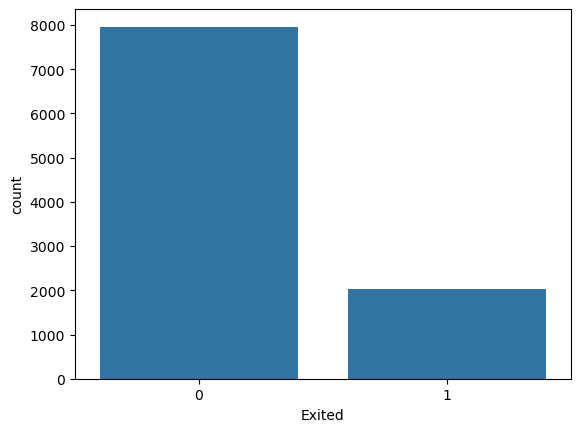

In [23]:
sb.countplot(x='Exited',data=churnfile_encoded)

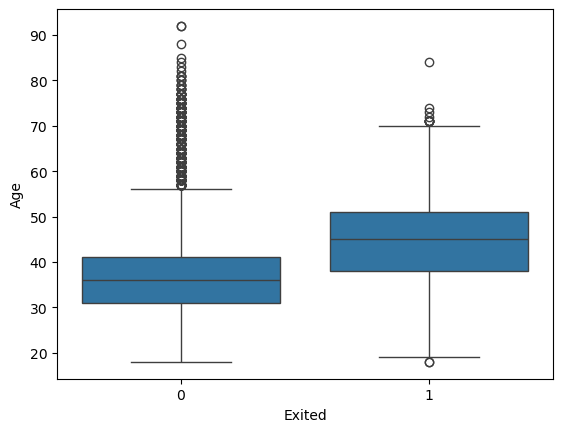

In [26]:
sb.boxplot(x='Exited',y='Age',data=churnfile_encoded)
mp.show()

In [14]:
y=churnfile_encoded['Exited']
X=churnfile_encoded.drop(columns='Exited')

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

Model Accuracy: 78.05%

Confusion Matrix:
[[1362  245]
 [ 194  199]]
--------------------------------------------------


C:\Users\Hp\AppData\Local\Temp\ipykernel_11076\513225384.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


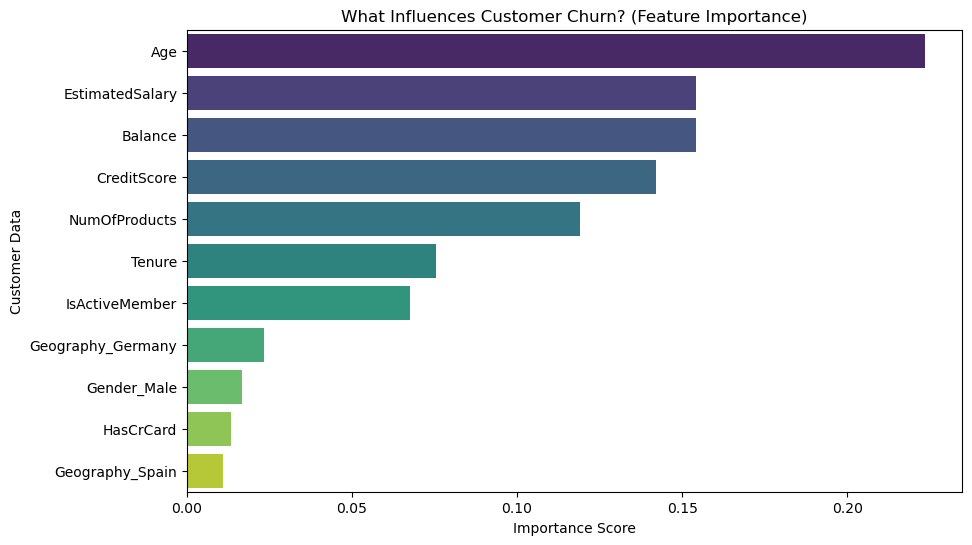

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("-" * 50)

importances = model.feature_importances_

feature_df = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': importances
})
feature_df = feature_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('What Influences Customer Churn? (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Customer Data')
plt.show()

The Conclusion: Model Evaluation & Business Insights

The Decision Tree model successfully predicted customer churn with an accuracy of 78.05%. More importantly, the feature importance analysis provided actionable business insights.

Based on the model's extraction, Age is the primary factor influencing whether a customer leaves the bank. Other significant factors include EstimatedSalary and Balance. To reduce churn, the bank should focus its retention strategies on customers who fall into the high-risk categories of these specific features, particularly older clients with high balances who may be looking for different types of financial security or services.